# Ejercicio 1 — Modelos LSTM

Series: `total`, `frontera_aurora`, `region_america_central`. Dos arquitecturas
para el avance: **M1** (LSTM simple) y **M2** (LSTM apilada con dropout).
Tuneo de hiperparámetros (grid search etapa A: `k` x `unidades` x `learning_rate`),
pronóstico multi-paso recursivo (mismo protocolo que el Lab 1: 63 meses hacia
adelante sin ver el conjunto de prueba) y comparación contra la línea base
del Laboratorio 1.

Las arquitecturas M3 (bidireccional) y M4 (sobre serie diferenciada) quedan definidas en
`src/lstm_utils.py` y se incorporan para la entrega final (2 de agosto).

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import datos as d
import lstm_utils as lu

lu.fijar_semilla()
MILES = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")

SERIES = ["total", "frontera_aurora", "region_america_central"]
ARQUITECTURAS = ["M1", "M2"]

panel = d.cargar_panel()
for nombre in SERIES:
    train, test = d.cargar_serie(nombre, panel)
    print(f"{nombre:26s} train {train.index.min():%Y-%m} -> {train.index.max():%Y-%m} "
          f"({len(train)} obs)  |  test {test.index.min():%Y-%m} -> {test.index.max():%Y-%m} ({len(test)} obs)")

total                      train 2009-01 -> 2021-03 (147 obs)  |  test 2021-04 -> 2026-06 (63 obs)
frontera_aurora            train 2009-01 -> 2021-03 (147 obs)  |  test 2021-04 -> 2026-06 (63 obs)
region_america_central     train 2009-01 -> 2021-03 (147 obs)  |  test 2021-04 -> 2026-06 (63 obs)


## Preprocesamiento

Para cada serie: `log1p` (tolera los ceros de la pandemia) -> `MinMaxScaler`
ajustado **solo con train** -> ventanas deslizantes. Se verifica el
round-trip de la transformación (log1p + escalado invertidos deben
reproducir los valores originales) antes de usarla para cualquier métrica.

In [2]:
for nombre in SERIES:
    train, _ = d.cargar_serie(nombre, panel)
    scaler = d.ajustar_transformacion(train)
    d.verificar_roundtrip(train, scaler)
    print(f"{nombre:26s} round-trip OK (log1p + MinMaxScaler, ajustado solo con train)")

total                      round-trip OK (log1p + MinMaxScaler, ajustado solo con train)
frontera_aurora            round-trip OK (log1p + MinMaxScaler, ajustado solo con train)
region_america_central     round-trip OK (log1p + MinMaxScaler, ajustado solo con train)


## Tuneo de hiperparámetros (grid search, etapa A)

Para cada serie y cada arquitectura (M1, M2) se barre `k` (ventana) x
`unidades` x `learning_rate`, con `batch_size` y `dropout` fijos. Se valida
con los últimos 24 meses de train (hold-out cronológico) y `EarlyStopping`
sobre `val_loss`. Se corrió una vez por separado y los resultados están en
`results/tuning_lstm.csv`; aquí se cargan y resumen (correrlo de nuevo desde
cero toma varios minutos).

In [3]:
tabla_tuneo = pd.read_csv("../results/tuning_lstm.csv")
print(f"Configuraciones evaluadas: {len(tabla_tuneo)}")
tabla_tuneo.sort_values("rmse_val_escalado").head(10)

Configuraciones evaluadas: 108


,serie,arquitectura,k,unidades,learning_rate,batch_size,dropout,epocas_efectivas,rmse_val_escalado,mae_val_escalado,tiempo_seg
88,region_america_central,M1,24,64,0.010,16,0.2,22,0.260986,0.196519,3.1
76,region_america_central,M1,6,64,0.010,16,0.2,21,0.264700,0.198370,3.1
72,region_america_central,M1,6,16,0.010,16,0.2,22,0.266345,0.200201,2.9
4,total,M1,6,64,0.010,16,0.2,21,0.270078,0.213416,3.3
73,region_america_central,M1,6,16,0.001,16,0.2,23,0.270124,0.217029,3.2
0,total,M1,6,16,0.010,16,0.2,22,0.270894,0.208340,3.4
82,region_america_central,M1,12,64,0.010,16,0.2,23,0.273433,0.220532,3.0
16,total,M1,24,64,0.010,16,0.2,22,0.273857,0.195323,3.7
74,region_america_central,M1,6,32,0.010,16,0.2,22,0.273874,0.197483,3.3
2,total,M1,6,32,0.010,16,0.2,22,0.275599,0.205122,3.3


In [4]:
mejores = tabla_tuneo.loc[tabla_tuneo.groupby(["serie", "arquitectura"])["rmse_val_escalado"].idxmin()]
mejores = mejores.sort_values(["serie", "arquitectura"]).reset_index(drop=True)
mejores.to_csv("../results/mejores_configuraciones.csv", index=False)
mejores[["serie", "arquitectura", "k", "unidades", "learning_rate",
         "batch_size", "dropout", "epocas_efectivas", "rmse_val_escalado"]]

,serie,arquitectura,k,unidades,learning_rate,batch_size,dropout,epocas_efectivas,rmse_val_escalado
0,frontera_aurora,M1,24,64,0.01,16,0.2,25,0.279100
1,frontera_aurora,M2,6,32,0.01,16,0.2,23,0.307772
2,region_america_central,M1,24,64,0.01,16,0.2,22,0.260986
3,region_america_central,M2,6,64,0.01,16,0.2,21,0.293334
4,total,M1,6,64,0.01,16,0.2,21,0.270078
5,total,M2,6,32,0.01,16,0.2,21,0.301704


**Lectura del tuneo:** para cada serie se identifica la mejor configuración
de M1 y de M2 por separado (RMSE de validación en escala transformada). Estas
son las configuraciones que se re-entrenan a continuación con el train
completo para producir el pronóstico de prueba.

## Re-entrenamiento con el train completo y pronóstico multi-paso recursivo

Con la mejor configuración de cada (serie, arquitectura), se re-entrena
usando los 147 meses completos de train (ya no se aparta validación) por el
número de épocas que el early stopping seleccionó. Después se pronostican
los 63 meses de prueba de forma **recursiva**: cada predicción se
realimenta como entrada del siguiente paso, sin usar ningún valor real de
prueba. Es el único protocolo comparable contra los modelos del Lab 1, que
también pronosticaron los 63 meses de una vez desde el final del train.

In [5]:
baseline_lab1 = d.cargar_baseline_lab1()
resultados_finales = []
predicciones = {}
series_cache = {}

for _, cfg in mejores.iterrows():
    serie, arq, k = cfg["serie"], cfg["arquitectura"], int(cfg["k"])
    unidades, lr = int(cfg["unidades"]), float(cfg["learning_rate"])
    batch_size, dropout = int(cfg["batch_size"]), float(cfg["dropout"])
    epocas = int(cfg["epocas_efectivas"])

    train, test = d.cargar_serie(serie, panel)
    scaler = d.ajustar_transformacion(train)
    train_escalado = d.aplicar_transformacion(train.values, scaler)
    X_full, y_full = d.crear_ventanas(train_escalado, k)

    modelo = lu.construir_modelo(arq, k=k, unidades=unidades, learning_rate=lr, dropout=dropout)
    modelo.fit(X_full, y_full, epochs=epocas, batch_size=batch_size, shuffle=False, verbose=0)

    ultima_ventana = train_escalado[-k:]
    pred_escalada = d.pronostico_recursivo(modelo, ultima_ventana, pasos=len(test))
    pred_original = d.invertir_transformacion(pred_escalada, scaler)

    metricas = d.evaluar(test.values, pred_original)
    resultados_finales.append({
        "serie": serie, "arquitectura": arq, "k": k, "unidades": unidades,
        "learning_rate": lr, "MAE": metricas["MAE"], "RMSE": metricas["RMSE"],
        "MAPE": metricas["MAPE"],
    })
    predicciones[f"{serie}_{arq}"] = pred_original
    series_cache[serie] = (train, test)
    modelo.save(f"../models/{serie}_{arq}.keras")
    print(f"{serie:26s} {arq}  MAE={metricas['MAE']:>12,.0f}  RMSE={metricas['RMSE']:>12,.0f}")

tabla_lstm = pd.DataFrame(resultados_finales)
tabla_lstm.to_csv("../results/pronostico_lstm_multi_paso.csv", index=False)
tabla_lstm

frontera_aurora            M1  MAE=      20,487  RMSE=      25,113


frontera_aurora            M2  MAE=      43,998  RMSE=      47,873


region_america_central     M1  MAE=      37,641  RMSE=      45,151


region_america_central     M2  MAE=     165,331  RMSE=     174,804


total                      M1  MAE=     149,862  RMSE=     163,454


total                      M2  MAE=      62,719  RMSE=      72,493


,serie,arquitectura,k,unidades,learning_rate,MAE,RMSE,MAPE
0,frontera_aurora,M1,24,64,0.01,20487.099290,25113.046754,20.958148
1,frontera_aurora,M2,6,32,0.01,43998.132522,47873.044411,53.415621
2,region_america_central,M1,24,64,0.01,37641.394695,45151.430889,31.703436
3,region_america_central,M2,6,64,0.01,165331.033048,174804.319997,114.474605
4,total,M1,6,64,0.01,149862.039170,163454.442722,68.959967
5,total,M2,6,32,0.01,62719.229522,72492.678612,34.873557


## Comparación contra el Laboratorio 1

Se toma, para cada serie, la mejor de las dos arquitecturas LSTM (por RMSE)
y se compara contra el mejor modelo clásico del Lab 1 (Prophet, Holt-Winters
o ARIMA según la serie), sobre el mismo conjunto de prueba de 63 meses.

In [6]:
comparacion = []
for serie in tabla_lstm["serie"].unique():
    sub = tabla_lstm[tabla_lstm["serie"] == serie].sort_values("RMSE")
    mejor_lstm = sub.iloc[0]
    base = baseline_lab1.loc[serie]
    comparacion.append({
        "serie": serie,
        "mejor_arquitectura_lstm": mejor_lstm["arquitectura"],
        "MAE_lstm": mejor_lstm["MAE"], "RMSE_lstm": mejor_lstm["RMSE"],
        "mejor_modelo_lab1": base["mejor_modelo"],
        "MAE_lab1": base["MAE"], "RMSE_lab1": base["RMSE"],
        "gana": "LSTM" if mejor_lstm["RMSE"] < base["RMSE"] else "Lab 1",
    })
tabla_comparacion = pd.DataFrame(comparacion)
tabla_comparacion.to_csv("../results/comparacion_lstm_vs_lab1.csv", index=False)
tabla_comparacion

,serie,mejor_arquitectura_lstm,MAE_lstm,RMSE_lstm,mejor_modelo_lab1,MAE_lab1,RMSE_lab1,gana
0,frontera_aurora,M1,20487.099290,25113.046754,Holt-Winters,25155.781732,30236.806620,LSTM
1,region_america_central,M1,37641.394695,45151.430889,Prophet,62484.786631,67837.603461,LSTM
2,total,M2,62719.229522,72492.678612,Prophet,132304.000000,139549.000000,LSTM


**Nota de lectura, importante:** el conjunto de entrenamiento termina en
2021-03, en el fondo del colapso pandémico; el conjunto de prueba es
íntegramente la recuperación 2021-2026. Ningún modelo entrenado solo con el
pasado puede anticipar la reapertura, así que los errores de prueba son
grandes para todos los modelos (LSTM y Lab 1 por igual) -- no es un fallo
puntual de una arquitectura, es una ruptura estructural del período
evaluado. La comparación válida es relativa: cuál modelo degrada menos, no
si predice bien en términos absolutos.

## Gráficos: pronóstico vs. real, por serie

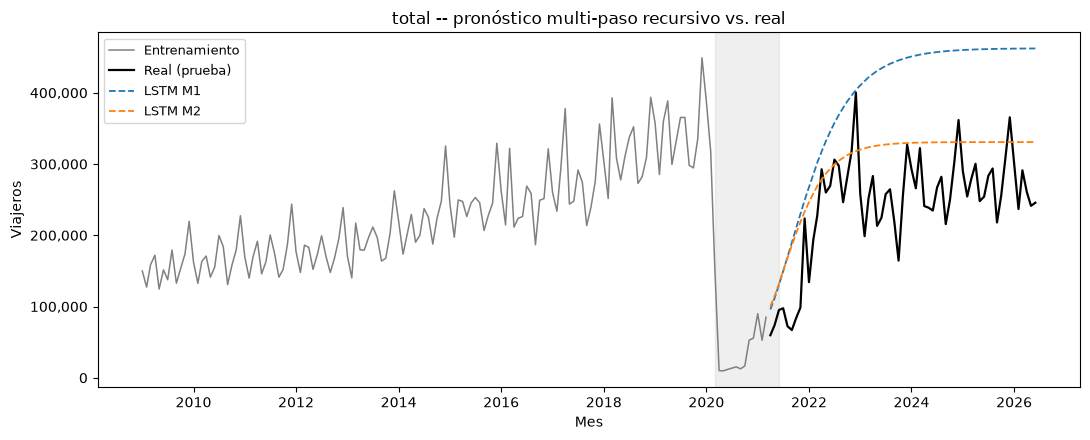

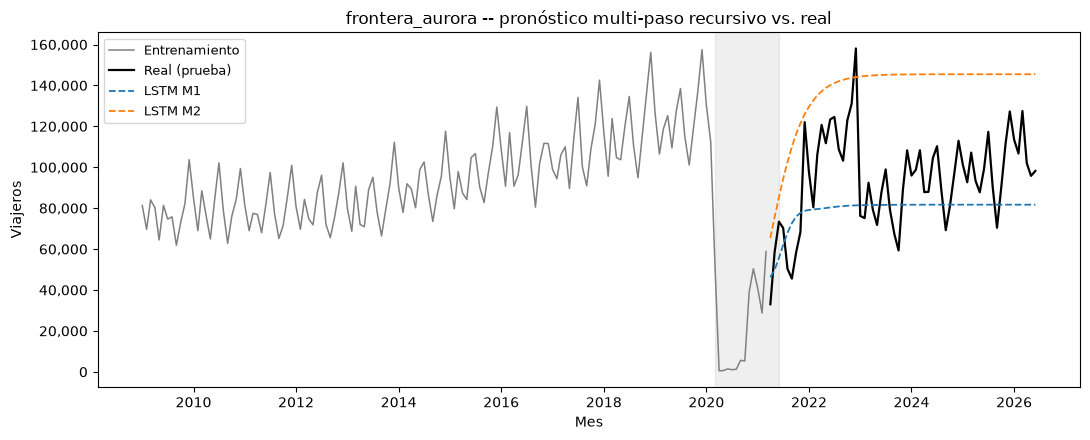

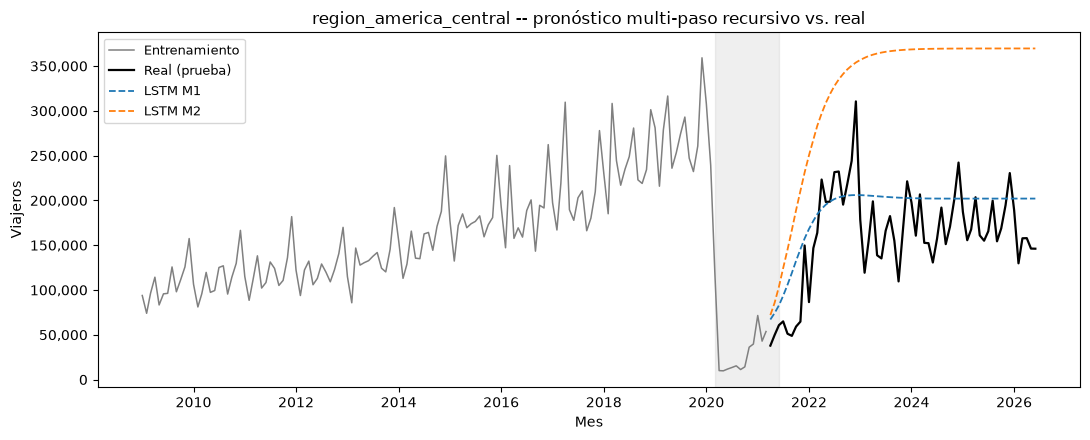

In [7]:
for serie in SERIES:
    train, test = series_cache[serie]
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(train.index, train.values, color="grey", lw=1.1, label="Entrenamiento")
    ax.plot(test.index, test.values, color="black", lw=1.6, label="Real (prueba)")
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-01"), color="grey", alpha=0.12)
    for arq in ARQUITECTURAS:
        pred = predicciones[f"{serie}_{arq}"]
        ax.plot(test.index, pred, lw=1.3, ls="--", label=f"LSTM {arq}")
    ax.set(title=f"{serie} -- pronóstico multi-paso recursivo vs. real", xlabel="Mes", ylabel="Viajeros")
    ax.yaxis.set_major_formatter(MILES)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(f"../figuras/pronostico_{serie}.png", dpi=110)
    plt.show()

## Conclusiones preliminares 

- Se entrenaron y tunearon dos arquitecturas LSTM (M1 simple, M2 apilada
  con dropout) para las tres series seleccionadas, mediante grid search
  sobre `k`, `unidades` y `learning_rate` (ver `results/tuning_lstm.csv`).
- El pronóstico de prueba se hizo de forma multi-paso recursiva, en las
  mismas condiciones que los modelos del Lab 1, para que la comparación de
  la tabla anterior sea válida.